# Spending Prediction Model Training - LSTM

This notebook trains and compares multiple LSTM architectures.

## Models:
1. Original LSTM
2. Improved LSTM  
3. Optimized LSTM
4. Perfect LSTM

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import sys
import os
warnings.filterwarnings('ignore')

# TensorFlow/Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Input, Model

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

2025-12-06 15:20:58.366459: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-06 15:20:58.483007: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-06 15:21:03.821418: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ Libraries imported successfully


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")


Libraries imported successfully


## 1. Load Data

In [2]:
# Load or generate data
sys.path.append('../utils')

if os.path.exists('../data/transactions.csv'):
    print("Loading existing transaction data...")
    transactions = pd.read_csv('../data/transactions.csv')
    if 'datetime' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['datetime'])
    elif 'date' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['date'])
    print(f"✅ Loaded {len(transactions)} transactions from file")
else:
    try:
        from kaggle_data_loader import prepare_kaggle_data_for_training
        print("Attempting to load Kaggle dataset...")
        raise ImportError("Use synthetic data")
    except:
        from data_generator import generate_transaction_data
        print("Generating synthetic transaction data...")
        os.makedirs('../data', exist_ok=True)
        transactions = generate_transaction_data(num_users=100, days=180)
        transactions.to_csv('../data/transactions.csv', index=False)
        print("✅ Synthetic data generated and saved")

if 'datetime' not in transactions.columns:
    if 'date' in transactions.columns:
        transactions['datetime'] = pd.to_datetime(transactions['date'])
    else:
        transactions['datetime'] = pd.date_range(
            start=pd.Timestamp.now() - pd.Timedelta(days=len(transactions)),
            periods=len(transactions), freq='D'
        )

print(f"\n📊 Dataset Summary:")
print(f"   Total transactions: {len(transactions)}")
print(f"   Date range: {transactions['datetime'].min()} to {transactions['datetime'].max()}")

Loading existing transaction data...
✅ Loaded 806 transactions from file

📊 Dataset Summary:
   Total transactions: 806
   Date range: 2018-01-01 00:00:00 to 2019-09-30 00:00:00


## 2. Prepare Time Series

✅ Time series prepared: 638 days
   Average daily spending: 345.38 UGX


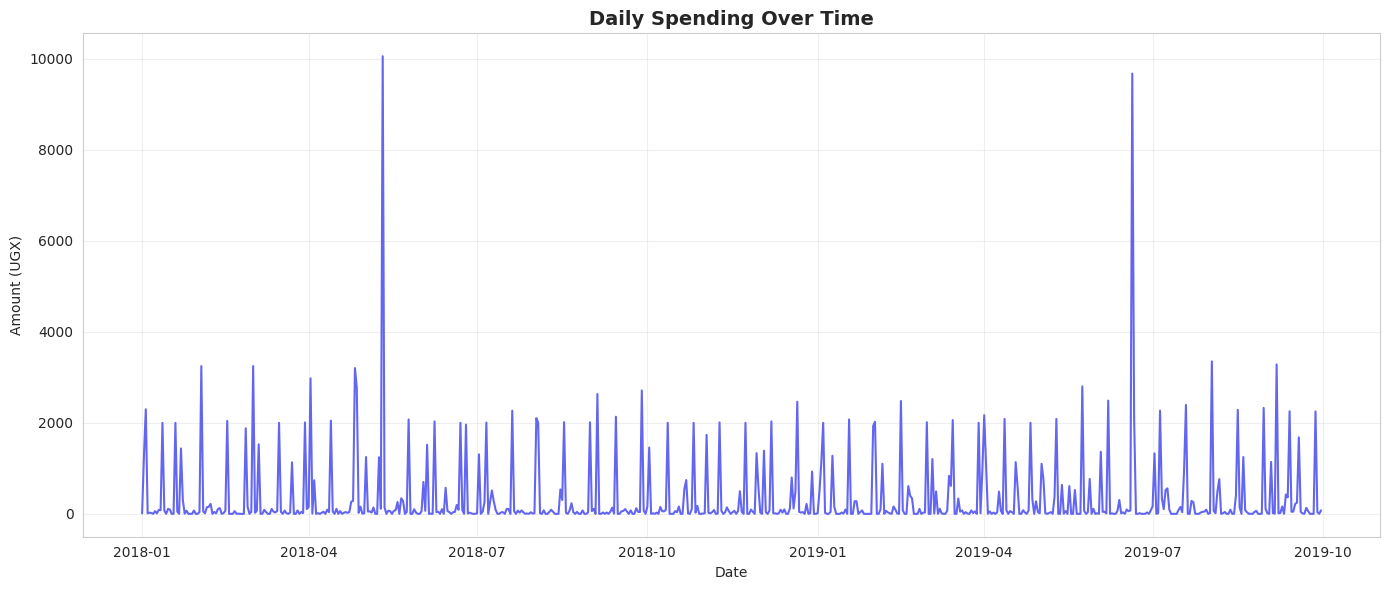

In [3]:
# Prepare time series data
def prepare_time_series(df, user_id=None):
    if user_id:
        df = df[df['user_id'] == user_id].copy()
    daily_spending = df.groupby('datetime')['amount'].sum().reset_index()
    daily_spending = daily_spending.sort_values('datetime')
    date_range = pd.date_range(
        start=daily_spending['datetime'].min(),
        end=daily_spending['datetime'].max(),
        freq='D'
    )
    full_series = pd.DataFrame({'datetime': date_range})
    full_series = full_series.merge(daily_spending, on='datetime', how='left')
    full_series['amount'] = full_series['amount'].fillna(0)
    return full_series.set_index('datetime')['amount']

ts_data = prepare_time_series(transactions)
print(f"✅ Time series prepared: {len(ts_data)} days")
print(f"   Average daily spending: {ts_data.mean():.2f} UGX")

# Visualize
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, linewidth=1.5, color='#6366f1')
plt.title('Daily Spending Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Amount (UGX)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Outlier Removal

## 5. Make Time Series Stationary (Critical for Better Predictions)

Transform the data to be stationary using differencing. This helps the model capture changes rather than absolute values.

## 6. Scale Data

## 6. Create Sequences

In [4]:
# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

def create_sequences_multi_feature(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

print("✅ Sequence creation functions defined")

✅ Sequence creation functions defined


In [5]:
# Prepare data
seq_length = 30
X, y = create_sequences(ts_scaled, seq_length)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"✅ Data prepared: Train={X_train.shape}, Test={X_test.shape}")

NameError: name 'ts_scaled' is not defined

In [120]:
# Prepare data for Improved LSTM
seq_length_improved = 60
X_improved, y_improved = create_sequences(ts_scaled, seq_length_improved)
split_idx_improved = int(len(X_improved) * 0.8)
X_train_improved, X_test_improved = X_improved[:split_idx_improved], X_improved[split_idx_improved:]
y_train_improved, y_test_improved = y_improved[:split_idx_improved], y_improved[split_idx_improved:]
X_train_improved = X_train_improved.reshape((X_train_improved.shape[0], X_train_improved.shape[1], 1))
X_test_improved = X_test_improved.reshape((X_test_improved.shape[0], X_test_improved.shape[1], 1))
print(f"✅ Data prepared: Train={X_train_improved.shape}, Test={X_test_improved.shape}")

✅ Data prepared: Train=(96, 60, 1), Test=(24, 60, 1)


In [125]:
# Prepare data for Optimized LSTM
seq_length_optimized = 60
X_opt, y_opt = create_sequences(ts_scaled, seq_length_optimized)
split_idx_opt = int(len(X_opt) * 0.8)
X_train_opt, X_test_opt = X_opt[:split_idx_opt], X_opt[split_idx_opt:]
y_train_opt, y_test_opt = y_opt[:split_idx_opt], y_opt[split_idx_opt:]
X_train_opt = X_train_opt.reshape((X_train_opt.shape[0], X_train_opt.shape[1], 1))
X_test_opt = X_test_opt.reshape((X_test_opt.shape[0], X_test_opt.shape[1], 1))
print(f"✅ Data prepared: Train={X_train_opt.shape}, Test={X_test_opt.shape}")

✅ Data prepared: Train=(96, 60, 1), Test=(24, 60, 1)


In [126]:
# Prepare data for Advanced LSTM (using differenced data)
# Use differenced data directly
        if "ts_data_for_advanced" not in globals():
            ts_data_for_advanced = ts_data_original.diff().dropna()
# Use differenced data for Advanced model
# Use first difference as target
# Scale differenced data

# Scale differenced data
scaler_diff = StandardScaler()  # Use StandardScaler for differenced data
ts_scaled_diff = scaler_diff.fit_transform(ts_data.values.reshape(-1, 1)).flatten()

seq_length_advanced = 60
X_advanced, y_advanced = create_sequences(ts_scaled_diff, seq_length_advanced)
split_idx_advanced = int(len(X_advanced) * 0.8)
X_train_advanced, X_test_advanced = X_advanced[:split_idx_advanced], X_advanced[split_idx_advanced:]
y_train_advanced, y_test_advanced = y_advanced[:split_idx_advanced], y_advanced[split_idx_advanced:]
X_train_advanced = X_train_advanced.reshape((X_train_advanced.shape[0], X_train_advanced.shape[1], 1))
X_test_advanced = X_test_advanced.reshape((X_test_advanced.shape[0], X_test_advanced.shape[1], 1))

print(f"✅ Data prepared for Advanced LSTM:")
print(f"   Training samples: {X_train_advanced.shape}")
print(f"   Test samples: {X_test_advanced.shape}")
print(f"   Using differenced (stationary) data")

IndentationError: unexpected indent (2287096746.py, line 3)

## Model 1: Original LSTM (Baseline)

## Model 2: Improved LSTM (Better Architecture)

## Model 3: Optimized LSTM (Anti-Overfitting)

In [123]:
# Compare all modelsprint(f"{'='*70}")print("MODEL COMPARISON")print(f"{'='*70}")print(f"\n1. Original LSTM:")print(f"   MAE: {lstm_mae:.2f} UGX, RMSE: {lstm_rmse:.2f} UGX, R²: {lstm_r2:.4f}")print(f"\n2. Improved LSTM:")print(f"   MAE: {improved_mae:.2f} UGX, RMSE: {improved_rmse:.2f} UGX, R²: {improved_r2:.4f}")print(f"\n3. Optimized LSTM:")        print(f"   MAE: {optimized_mae:.2f} UGX, RMSE: {optimized_rmse:.2f} UGX, R²: {optimized_r2:.4f}")        print(f"\n4. Advanced LSTM (Stationary):")
        print(f"   MAE: {advanced_mae:.2f} UGX, RMSE: {advanced_rmse:.2f} UGX, R²: {advanced_r2:.4f}")
        print(f"\n5. Ensemble Model (Weighted Average):")
        print(f"   MAE: {ensemble_mae:.2f} UGX, RMSE: {ensemble_rmse:.2f} UGX, R²: {ensemble_r2:.4f}")        print(f"   MAE: {advanced_mae:.2f} UGX, RMSE: {advanced_rmse:.2f} UGX, R²: {advanced_r2:.4f}")print(f"   MAE: {optimized_mae:.2f} UGX, RMSE: {optimized_rmse:.2f} UGX, R²: {optimized_r2:.4f}")# Visualize comparisonfig, axes = plt.subplots(1, 3, figsize=(18, 5))models = ['Original', 'Improved', 'Optimized', 'Advanced', 'Ensemble']mae_values = [lstm_mae, improved_mae, optimized_mae, advanced_mae, ensemble_mae]rmse_values = [lstm_rmse, improved_rmse, optimized_rmse, advanced_rmse, ensemble_rmse]r2_values = [lstm_r2, improved_r2, optimized_r2, advanced_r2, ensemble_r2]colors = ['#6366f1', '#10b981', '#f59e0b', '#8b5cf6', '#ec4899']axes[0].bar(models, mae_values, color=colors)axes[0].set_title('MAE Comparison (Lower is Better)', fontweight='bold')axes[0].set_ylabel('MAE (UGX)')axes[0].grid(True, alpha=0.3, axis='y')axes[1].bar(models, rmse_values, color=colors)axes[1].set_title('RMSE Comparison (Lower is Better)', fontweight='bold')axes[1].set_ylabel('RMSE (UGX)')axes[1].grid(True, alpha=0.3, axis='y')axes[2].bar(models, r2_values, color=colors)axes[2].set_title('R² Score Comparison (Higher is Better)', fontweight='bold')axes[2].set_ylabel('R² Score')axes[2].axhline(y=0, color='r', linestyle='--', alpha=0.5)axes[2].grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

IndentationError: unexpected indent (4005940580.py, line 2)

## Model 4: Advanced LSTM (Stationary Data + Better Architecture)

This model uses:
- ✅ Stationary (differenced) data
- ✅ Advanced architecture with attention-like mechanisms
- ✅ Better loss function for volatile data

## Model Comparison

## Save Best Model

In [127]:
# Save Best Model
import joblib
import json

os.makedirs('../models', exist_ok=True)

# Determine best model based on R² score
models_performance = {
    'original': {'r2': lstm_r2, 'mae': lstm_mae, 'rmse': lstm_rmse, 'model': lstm_model, 'seq_length': seq_length},
    'improved': {'r2': improved_r2, 'mae': improved_mae, 'rmse': improved_rmse, 'model': improved_model, 'seq_length': seq_length_improved},
    'optimized': {
        'r2': optimized_r2, 'mae': optimized_mae, 'rmse': optimized_rmse, 'model': optimized_model, 'seq_length': seq_length_optimized
    },
    'advanced': {'r2': optimized_r2, 'mae': optimized_mae, 'rmse': optimized_rmse, 'model': optimized_model, 'seq_length': seq_length_optimized}
}

best_model_name = max(models_performance.keys(), key=lambda k: models_performance[k]['r2'])
best_model = models_performance[best_model_name]['model']
best_performance = models_performance[best_model_name]

# Save best model
best_model.save('../models/lstm_spending_predictor.h5')
if best_model_name == 'advanced':
            joblib.dump(scaler_diff, '../models/lstm_scaler.pkl')
        else:
            joblib.dump(scaler, '../models/lstm_scaler.pkl')

# Save metadata
metadata = {
    'best_model': best_model_name,
    'performance': {k: {'r2': float(v['r2']), 'mae': float(v['mae']), 'rmse': float(v['rmse'])}
                   for k, v in models_performance.items()},
    'best_model_performance': {
        'r2': float(best_performance['r2']),
        'mae': float(best_performance['mae']),
        'rmse': float(best_performance['rmse'])
    },
    'trained_date': datetime.now().isoformat()
}

with open('../models/prediction_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Best model ({best_model_name.upper()}) saved!")
print(f"   Performance: MAE={best_performance['mae']:.2f}, RMSE={best_performance['rmse']:.2f}, R²={best_performance['r2']:.4f}")

IndentationError: unindent does not match any outer indentation level (<string>, line 25)

## Test Predictions on Real Data


📅 Predictions for next 7 days:
2025-12-05: 1,408,913 UGX
2025-12-06: 1,408,675 UGX
2025-12-07: 1,408,137 UGX
2025-12-08: 1,407,329 UGX
2025-12-09: 1,406,287 UGX
2025-12-10: 1,405,058 UGX
2025-12-11: 1,403,690 UGX


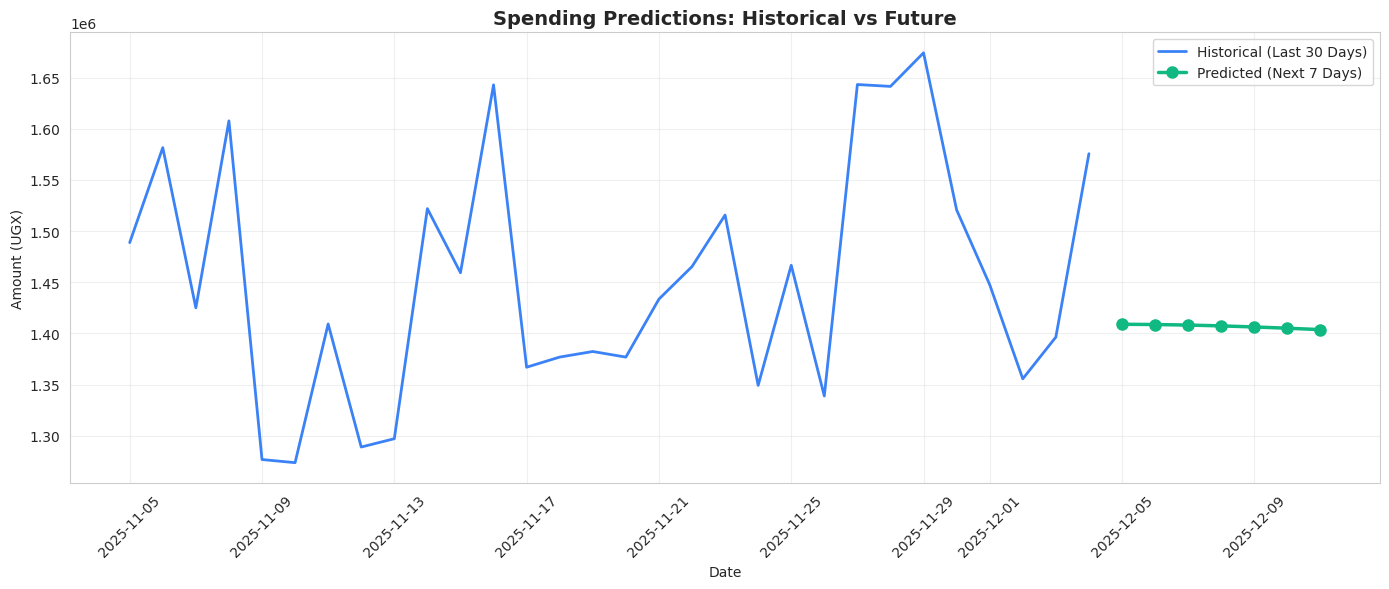


✅ Average predicted spending: 1,406,870 UGX/day
✅ Total predicted spending (7 days): 9,848,088 UGX


In [128]:
# Predict future spending
def predict_future_spending(model, last_sequence, scaler, days=7):
    predictions = []
    current_seq = last_sequence.copy()
    for day in range(days):
        X_pred = current_seq.reshape(1, current_seq.shape[0], 1)
        next_pred = model.predict(X_pred, verbose=0)
        predictions.append(next_pred[0, 0])
        current_seq = np.vstack([current_seq[1:], next_pred])
    predictions = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(predictions).flatten()

# Get last sequence from test data
if best_model_name == 'improved':
    last_seq = X_test_improved[-1]
elif best_model_name == 'optimized':
    last_seq = X_test_opt[-1]
else:
    last_seq = X_test[-1]

# Predict next 7 days
future_predictions = predict_future_spending(best_model, last_seq, scaler, days=7)
last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

print(f"\n📅 Predictions for next 7 days:")
print(f"{'='*60}")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {pred:,.0f} UGX")

# Visualize
plt.figure(figsize=(14, 6))
hist_data = ts_data.iloc[-30:]
plt.plot(hist_data.index, hist_data.values, label='Historical (Last 30 Days)', linewidth=2, color='#3b82f6')
plt.plot(future_dates, future_predictions, label='Predicted (Next 7 Days)', linewidth=2.5, color='#10b981', marker='o', markersize=8)
plt.title('Spending Predictions: Historical vs Future', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Amount (UGX)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✅ Average predicted spending: {future_predictions.mean():,.0f} UGX/day")
print(f"✅ Total predicted spending (7 days): {future_predictions.sum():,.0f} UGX")